<a href="https://colab.research.google.com/github/MuhammadSarimUmer/Retail.Data_EDA_visualization/blob/main/Retail_Data_EDA_%26_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
df = pd.read_csv('retail_sales.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      1825 non-null   object 
 1   Category  1821 non-null   object 
 2   Sales     1823 non-null   float64
 3   Quantity  1820 non-null   float64
 4   Profit    1825 non-null   float64
 5   Region    1820 non-null   object 
dtypes: float64(3), object(3)
memory usage: 85.7+ KB


In [68]:
df.shape
print("Rows in this dataset are 1825, cols are 6 originally")
print("Original data types from the data are Date(obj),Category(obj),Sales(float),Quantity(float),Profit(float) and Region")


Rows in this dataset are 1825, cols are 6 originally
Original data types from the data are Date(obj),Category(obj),Sales(float),Quantity(float),Profit(float) and Region


In [69]:
missing_values=df.isnull().sum()
print(f"Missing values in the original data are {missing_values}")
duplicated_data = df.duplicated().sum()
print(f"Duplicated data in the original data is {duplicated_data}")

Missing values in the original data are Date        0
Category    4
Sales       2
Quantity    5
Profit      0
Region      5
dtype: int64
Duplicated data in the original data is 0


In [70]:
df['Category'] = df['Category'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Date'].head()

,Date
0,1/1/2023
1,1/1/2023
2,1/1/2023
3,1/1/2023
4,1/1/2023


In [71]:

df['Date'] = pd.to_datetime(df['Date'], format='mixed')
df['Date_Day']   = df['Date'].dt.day
df['Date_Month'] = df['Date'].dt.month
df['Date_Year']  = df['Date'].dt.year
df['Day_of_Week'] = df['Date'].dt.dayofweek
print("=== Dtypes After Extraction ===")
print(df[['Date', 'Date_Day', 'Date_Month', 'Date_Year', 'Day_of_Week']].dtypes)
print("\n=== First 5 Rows of Engineered Features ===")
df[['Date', 'Date_Day', 'Date_Month', 'Date_Year', 'Day_of_Week']].head()


=== Dtypes After Extraction ===
Date           datetime64[ns]
Date_Day                int32
Date_Month              int32
Date_Year               int32
Day_of_Week             int32
dtype: object

=== First 5 Rows of Engineered Features ===


,Date,Date_Day,Date_Month,Date_Year,Day_of_Week
0,2023-01-01,1,1,2023,6
1,2023-01-01,1,1,2023,6
2,2023-01-01,1,1,2023,6
3,2023-01-01,1,1,2023,6
4,2023-01-01,1,1,2023,6


In [78]:

category_mode=df['Category'].mode()[0]
region_mode = df['Region'].mode()[0]
quantity_median = df['Quantity'].median()
sales_median=df['Sales'].median()
df['Category'].fillna(category_mode,inplace=True)
df['Region'].fillna(region_mode,inplace=True)
df['Quantity'].fillna(quantity_median,inplace=True)
df['Sales'].fillna(sales_median,inplace=True)
print("Missing values are replaced with mean and median")
cat_mode = df[~df['Category'].isin(['Null', 'Nan', 'NaN?'])]['Category'].mode()[0]
df['Category'] = df['Category'].replace(['Null', 'Nan', 'NaN?'], cat_mode)

reg_mode = df[~df['Region'].isin(['Nan'])]['Region'].mode()[0]
df['Region'] = df['Region'].replace(['Nan'], reg_mode)


Missing values are replaced with mean and median


/tmp/ipykernel_9920/451492809.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Category'].fillna(category_mode,inplace=True)
/tmp/ipykernel_9920/451492809.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [73]:
df.skew(numeric_only=True)


,0
Sales,-0.487265
Quantity,-0.018573
Profit,0.670212
Date_Day,0.007527
Date_Month,-0.010465
Date_Year,0.000000
Day_of_Week,-0.003111


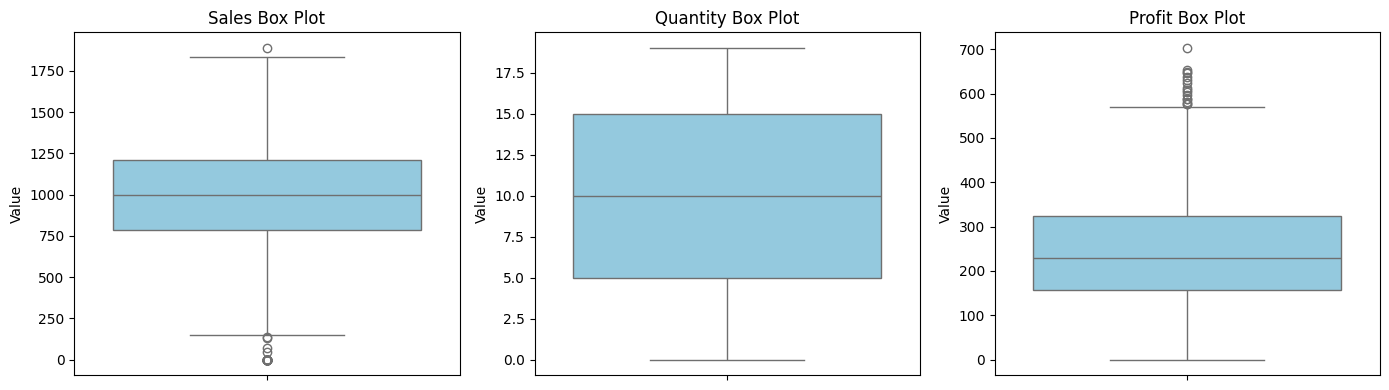

=== MATHEMATICAL OUTLIER REPORT (IQR METHOD) ===
Column 'Sales':
  -> Acceptable range: 148.42 to 1844.01
  -> Total Outlier Rows Found: 50 out of 1825 total rows
--------------------------------------------------
Column 'Quantity':
  -> Acceptable range: -10.00 to 30.00
  -> Total Outlier Rows Found: 0 out of 1825 total rows
--------------------------------------------------
Column 'Profit':
  -> Acceptable range: -95.01 to 576.79
  -> Total Outlier Rows Found: 16 out of 1825 total rows
--------------------------------------------------


In [74]:


relevant_cols = ['Sales', 'Quantity', 'Profit']

plt.figure(figsize=(14, 4))

for i, col in enumerate(relevant_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col} Box Plot')
    plt.ylabel('Value')

plt.tight_layout()
plt.show()

print("=== MATHEMATICAL OUTLIER REPORT (IQR METHOD) ===")

for col in relevant_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"Column '{col}':")
    print(f"  -> Acceptable range: {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"  -> Total Outlier Rows Found: {len(outliers)} out of {len(df)} total rows")
    print("-" * 50)

In [75]:

df['Sales'] = df['Sales'].clip(lower=147.41, upper=1845.17)
df['Profit'] = df['Profit'].clip(lower=-95.01, upper=576.79)
print("=== OUTLIERS SUCCESSFULLY CLIPPED ===")
relevant_cols = ['Sales', 'Quantity', 'Profit']
print("\n=== RE-RUNNING MATHEMATICAL OUTLIER REPORT ===")
for col in relevant_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_left = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Column '{col}': Total Outlier Rows Remaining -> {len(outliers_left)}")

=== OUTLIERS SUCCESSFULLY CLIPPED ===

=== RE-RUNNING MATHEMATICAL OUTLIER REPORT ===
Column 'Sales': Total Outlier Rows Remaining -> 50
Column 'Quantity': Total Outlier Rows Remaining -> 0
Column 'Profit': Total Outlier Rows Remaining -> 0


                Sales  Quantity    Profit  Date_Day  Date_Month  Date_Year  \
Sales        1.000000  0.055314  0.540242 -0.021731    0.056104        NaN   
Quantity     0.055314  1.000000  0.027775 -0.035270    0.003159        NaN   
Profit       0.540242  0.027775  1.000000 -0.017535   -0.035234        NaN   
Date_Day    -0.021731 -0.035270 -0.017535  1.000000    0.011893        NaN   
Date_Month   0.056104  0.003159 -0.035234  0.011893    1.000000        NaN   
Date_Year         NaN       NaN       NaN       NaN         NaN        NaN   
Day_of_Week  0.007307 -0.020405  0.028110 -0.012152    0.012860        NaN   

             Day_of_Week  
Sales           0.007307  
Quantity       -0.020405  
Profit          0.028110  
Date_Day       -0.012152  
Date_Month      0.012860  
Date_Year            NaN  
Day_of_Week     1.000000  


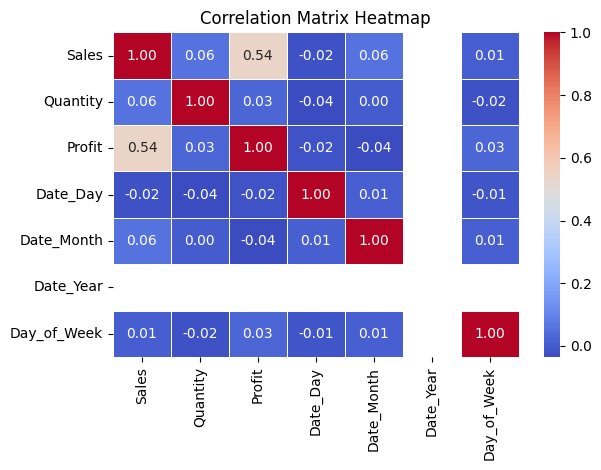

In [76]:
relevant_cols = ['Sales', 'Quantity', 'Profit', 'Date_Day', 'Date_Month', 'Date_Year', 'Day_of_Week']
corr_matrix = df[relevant_cols].corr()

print(corr_matrix)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')

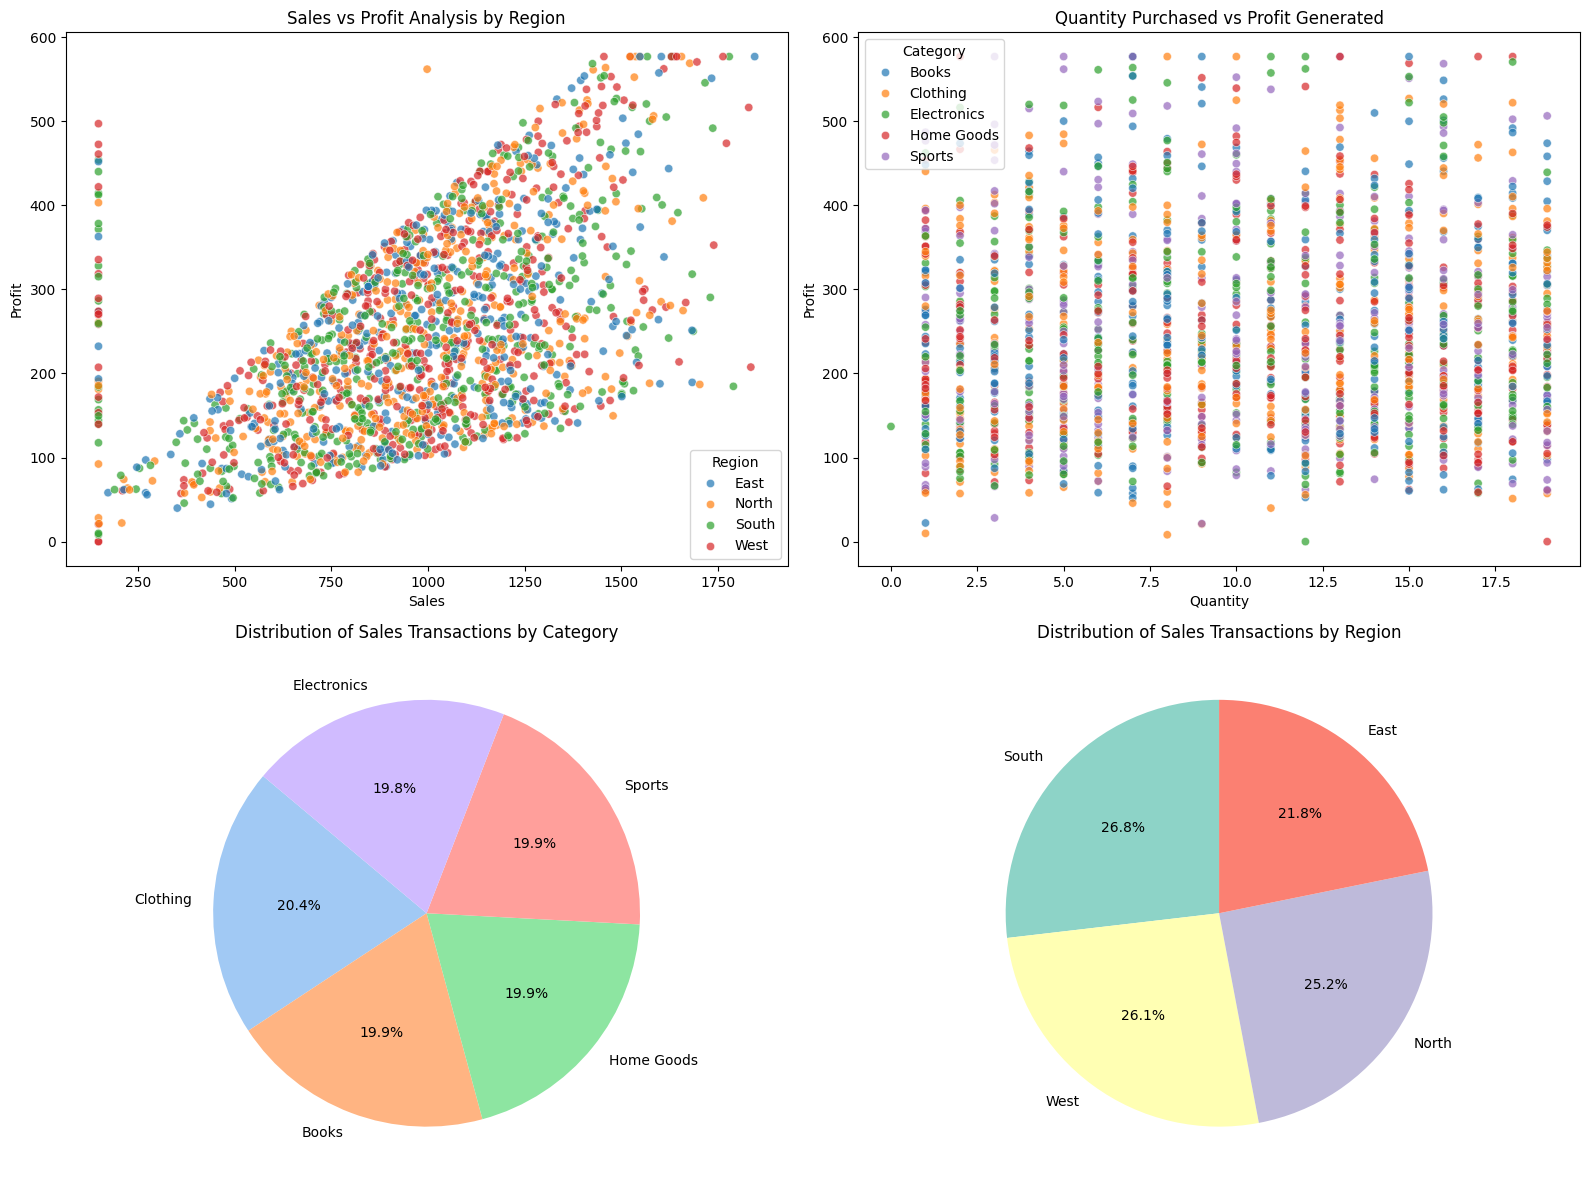

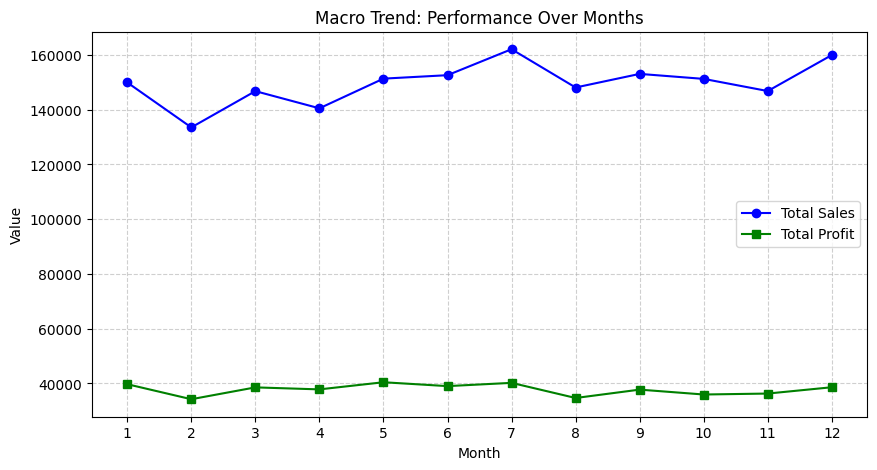

                BUSINESS INSIGHTS REPORT                 

--- 1. TOP PERFORMING SEGMENTS ---
Performance metrics grouped by product family:
                     Sales        Profit
Category                                
Books        371856.332558  92148.000114
Sports       349130.992999  91977.151645
Clothing     359550.342877  91513.912810
Electronics  366709.641422  90199.793965
Home Goods   348967.927088  87383.781478


--- 2. GEOGRAPHIC PERFORMANCE ---
Performance metrics grouped by territory logistics:
                Sales         Profit
Region                              
West    473031.586896  122284.244018
South   477855.937774  120062.154915
North   450195.085168  112013.594305
East    395132.627106   98862.646773


--- 3. KEY EFFICIENCY RATIOS ---
Overall Corporate Net Profit Margin : 25.23%
Mean Product Volume Per Transaction : 10.05 units
Strongest Single Linear Connection  : Sales vs Profit Correlation Coefficient is 0.54



/tmp/ipykernel_9920/540150163.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_perf = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
/tmp/ipykernel_9920/540150163.py:63: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)


In [79]:


fig, axes = plt.subplots(2, 2, figsize=(16, 12))


sns.scatterplot(data=df, x='Sales', y='Profit', hue='Region', alpha=0.7, ax=axes[0, 0])
axes[0, 0].set_title('Sales vs Profit Analysis by Region')
axes[0, 0].set_xlabel('Sales')
axes[0, 0].set_ylabel('Profit')


sns.scatterplot(data=df, x='Quantity', y='Profit', hue='Category', alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Quantity Purchased vs Profit Generated')
axes[0, 1].set_xlabel('Quantity')
axes[0, 1].set_ylabel('Profit')


category_counts = df['Category'].value_counts()
axes[1, 0].pie(category_counts, labels=category_counts.index, autopct='%1.1f%%',
               colors=sns.color_palette('pastel'), startangle=140)
axes[1, 0].set_title('Distribution of Sales Transactions by Category')


region_counts = df['Region'].value_counts()
axes[1, 1].pie(region_counts, labels=region_counts.index, autopct='%1.1f%%',
               colors=sns.color_palette('Set3'), startangle=90)
axes[1, 1].set_title('Distribution of Sales Transactions by Region')

plt.tight_layout()
plt.show()


monthly_performance = df.groupby('Date_Month')[['Sales', 'Profit']].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.plot(monthly_performance['Date_Month'], monthly_performance['Sales'], marker='o', label='Total Sales', color='b')
plt.plot(monthly_performance['Date_Month'], monthly_performance['Profit'], marker='s', label='Total Profit', color='g')
plt.title('Macro Trend: Performance Over Months')
plt.xlabel('Month')
plt.ylabel('Value')
plt.xticks(monthly_performance['Date_Month'])
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



print("==========================================================")
print("                BUSINESS INSIGHTS REPORT                 ")
print("==========================================================\n")

print("--- 1. TOP PERFORMING SEGMENTS ---")
category_perf = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
print("Performance metrics grouped by product family:")
print(category_perf.to_string())
print("\n")

print("--- 2. GEOGRAPHIC PERFORMANCE ---")
region_perf = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False)
print("Performance metrics grouped by territory logistics:")
print(region_perf.to_string())
print("\n")

print("--- 3. KEY EFFICIENCY RATIOS ---")
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit / total_sales) * 100
avg_quantity_per_order = df['Quantity'].mean()

print(f"Overall Corporate Net Profit Margin : {overall_margin:.2f}%")
print(f"Mean Product Volume Per Transaction : {avg_quantity_per_order:.2f} units")
print(f"Strongest Single Linear Connection  : Sales vs Profit Correlation Coefficient is {df['Sales'].corr(df['Profit']):.2f}")
print("\n==========================================================")

/tmp/ipykernel_9920/1006789208.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_data, x='Day_of_Week', y='Sales', palette='Blues_d', ax=ax)


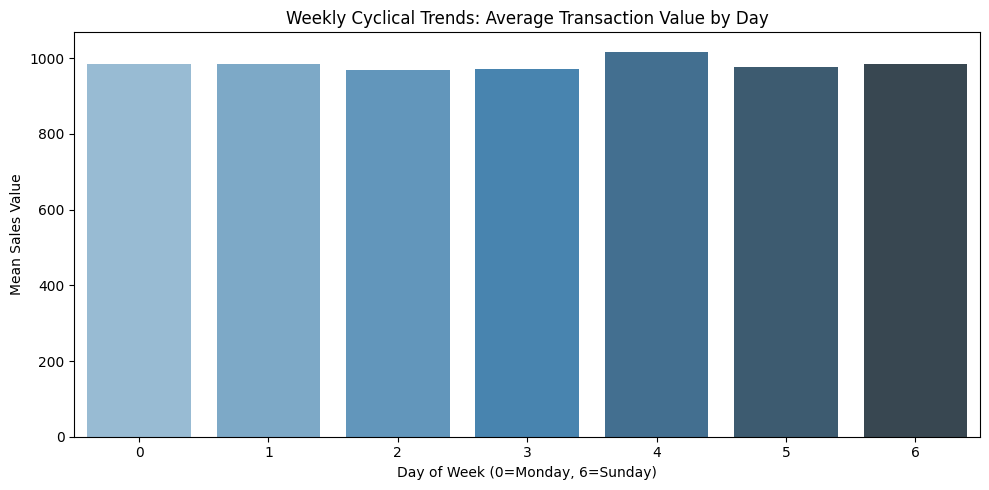

=== CLEANED SEGMENT REPORT ===
                     Sales        Profit
Category                                
Books        371856.332558  92148.000114
Sports       349130.992999  91977.151645
Clothing     359550.342877  91513.912810
Electronics  366709.641422  90199.793965
Home Goods   348967.927088  87383.781478

=== CLEANED GEOGRAPHIC REPORT ===
                Sales         Profit
Region                              
West    473031.586896  122284.244018
South   477855.937774  120062.154915
North   450195.085168  112013.594305
East    395132.627106   98862.646773

=== SEASONAL TREND DATA ===
 Date_Month         Sales       Profit
          1 149959.776812 39711.436221
          2 133542.101776 34226.685194
          3 146795.300626 38552.589267
          4 140519.551209 37822.357720
          5 151364.617103 40430.580033
          6 152623.616965 39014.835478
          7 162111.115687 40205.619625
          8 148124.205693 34675.627875
          9 153094.700793 37733.031001
      

/tmp/ipykernel_9920/1006789208.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False))
/tmp/ipykernel_9920/1006789208.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False))


In [82]:
monthly_data = df.groupby('Date_Month')[['Sales', 'Profit']].sum().reset_index()
weekday_data = df.groupby('Day_of_Week')[['Sales', 'Profit']].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_data['Date_Month'], monthly_data['Sales'], marker='o', color='royalblue', linewidth=2, label='Total Sales')
ax.plot(monthly_data['Date_Month'], monthly_data['Profit'], marker='s', color='forestgreen', linewidth=2, label='Total Profit')
ax.set_title('Monthly Macro Trends: Revenue vs Profit Tracking')
ax.set_xlabel('Month of Year')
ax.set_ylabel('Total Financial Volume')
ax.set_xticks(monthly_data['Date_Month'])
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
plt.tight_layout()
plt.savefig('monthly_macro_trends.png', bbox_inches='tight')
plt.close()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=weekday_data, x='Day_of_Week', y='Sales', palette='Blues_d', ax=ax)
ax.set_title('Weekly Cyclical Trends: Average Transaction Value by Day')
ax.set_xlabel('Day of Week (0=Monday, 6=Sunday)')
ax.set_ylabel('Mean Sales Value')
plt.tight_layout()
plt.show()
plt.savefig('weekday_sales_performance.png', bbox_inches='tight')
plt.close()

print("=== CLEANED SEGMENT REPORT ===")
print(df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False))
print("\n=== CLEANED GEOGRAPHIC REPORT ===")
print(df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False))
print("\n=== SEASONAL TREND DATA ===")
print(monthly_data.to_string(index=False))
print("\n=== WEEKDAY CYCLICAL DATA ===")
print(weekday_data.to_string(index=False))


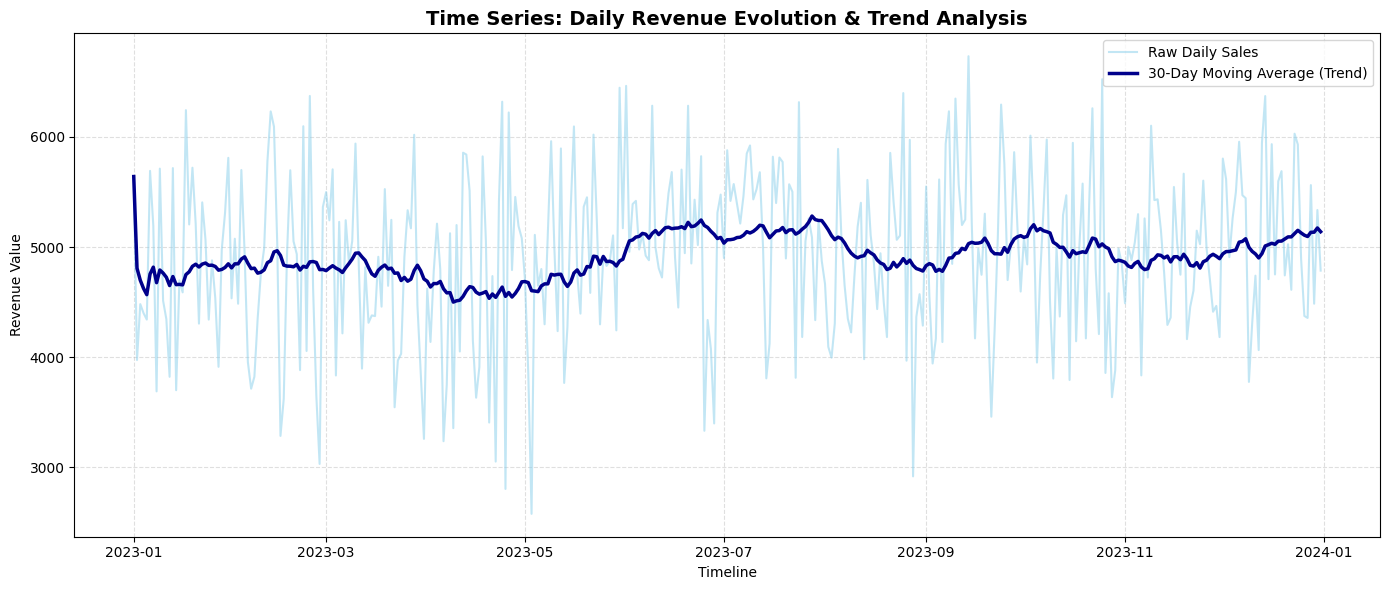

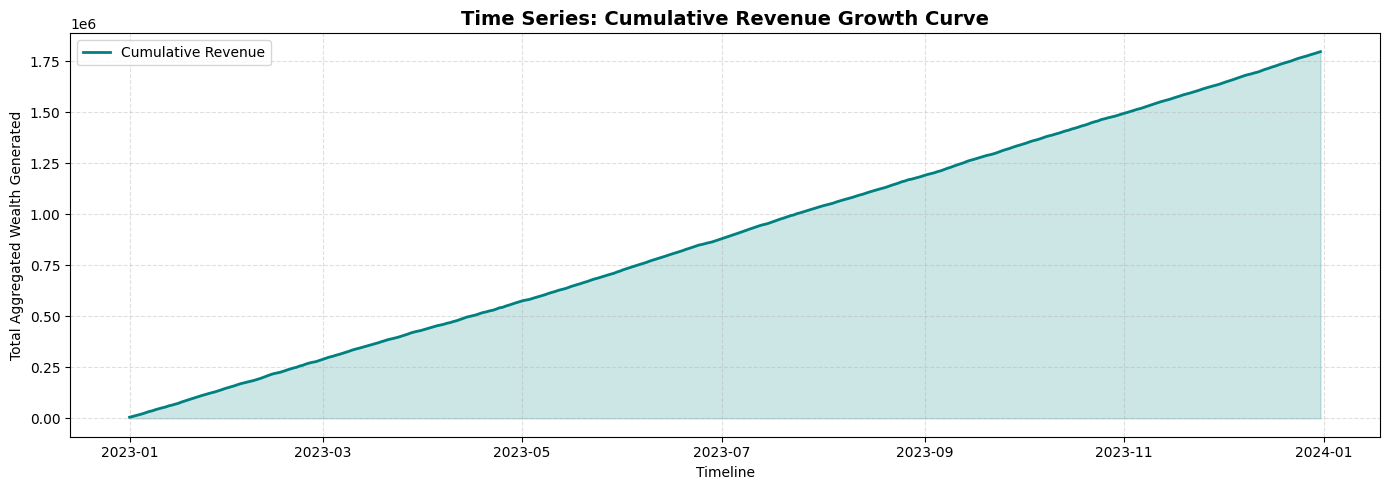

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

df_sorted = df.sort_values(by='Date')

daily_ts = df_sorted.groupby('Date')[['Sales', 'Profit']].sum().reset_index()


daily_ts['Sales_30D_Mean'] = daily_ts['Sales'].rolling(window=30, min_periods=1).mean()


daily_ts['Cumulative_Sales'] = daily_ts['Sales'].cumsum()

plt.figure(figsize=(14, 6))

plt.plot(daily_ts['Date'], daily_ts['Sales'], color='skyblue', alpha=0.5, label='Raw Daily Sales')

plt.plot(daily_ts['Date'], daily_ts['Sales_30D_Mean'], color='darkblue', linewidth=2.5, label='30-Day Moving Average (Trend)')

plt.title('Time Series: Daily Revenue Evolution & Trend Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Revenue Value')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print("\n" + "="*70 + "\n")

plt.figure(figsize=(14, 5))
plt.fill_between(daily_ts['Date'], daily_ts['Cumulative_Sales'], color='teal', alpha=0.2)
plt.plot(daily_ts['Date'], daily_ts['Cumulative_Sales'], color='teal', linewidth=2, label='Cumulative Revenue')

plt.title('Time Series: Cumulative Revenue Growth Curve', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Total Aggregated Wealth Generated')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()